# MocoInverse: 3-Condition Comparison
**Baseline** (human only) vs **Exo Locked** (mass only) vs **Exo Active** (hip assistance)

Run from: `~/repos/projects/exo-assist-pipeline/opensim/moco-experiments/`

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
%matplotlib inline
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 9

## 1. Load Solutions

In [2]:
BASE_DIR = os.path.expanduser(
    '~/repos/projects/exo-assist-pipeline/opensim/moco-experiments')

SOLUTIONS = {
    'Baseline': os.path.join(BASE_DIR, 'baseline',
                             'baseline_MocoInverse_solution.sto'),
    'Exo locked': os.path.join(BASE_DIR, 'exo_locked',
                               'exo_locked_MocoInverse_solution.sto'),
    'Exo active': os.path.join(BASE_DIR, 'exo_active',
                               'exo_active_MocoInverse_solution.sto'),
}

COLORS = {
    'Baseline': '#2196F3',
    'Exo locked': '#FF9800',
    'Exo active': '#4CAF50',
}

def read_sto(filepath):
    """Read .sto file -> (time, col_names, data_dict)."""
    with open(filepath) as f:
        for i, line in enumerate(f):
            if line.strip() == 'endheader':
                header_lines = i + 1
                break
    with open(filepath) as f:
        for _ in range(header_lines):
            next(f)
        col_names = next(f).strip().split('\t')
        rows = []
        for line in f:
            vals = line.strip().split('\t')
            if len(vals) == len(col_names):
                rows.append([float(v) for v in vals])
    data = np.array(rows)
    return data[:, 0], col_names, {n: data[:, j] for j, n in enumerate(col_names)}

def find_col(col_names, muscle):
    """Find excitation column for a muscle."""
    for col in col_names:
        if f'/forceset/{muscle}' in col and 'reserve' not in col.lower():
            return col
    for col in col_names:
        if muscle in col and 'reserve' not in col.lower() and col != 'time':
            return col
    return None

def to_gait_pct(time, data, n=101):
    """Normalize to 0-100% gait cycle."""
    t_pct = np.linspace(0, 100, n)
    t_norm = (time - time[0]) / (time[-1] - time[0]) * 100
    return t_pct, np.interp(t_pct, t_norm, data)

# Load
sols = {}
for label, path in SOLUTIONS.items():
    if not os.path.exists(path):
        print(f'MISSING: {path}')
        continue
    t, cn, dd = read_sto(path)
    sols[label] = {'time': t, 'cols': cn, 'data': dd}
    print(f'{label}: {len(t)} steps, t=[{t[0]:.3f}, {t[-1]:.3f}]s, {len(cn)} cols')

Baseline: 115 steps, t=[0.480, 1.610]s, 254 cols
Exo locked: 115 steps, t=[0.480, 1.610]s, 254 cols
Exo active: 115 steps, t=[0.480, 1.610]s, 192 cols


## 2. Quick sanity check — list column names

In [3]:
# Show muscle/actuator columns from exo_active
if 'Exo active' in sols:
    active_cols = sols['Exo active']['cols']
    muscle_cols = [c for c in active_cols if '/forceset/' in c]
    exo_cols = [c for c in active_cols if 'exo' in c.lower()]
    reserve_cols = [c for c in active_cols if 'reserve' in c.lower()]
    print(f'Total forceset columns: {len(muscle_cols)}')
    print(f'Exo actuator columns: {exo_cols}')
    print(f'Reserve columns: {reserve_cols}')
    print(f'\nFirst 10 muscle cols:')
    for c in muscle_cols[:10]:
        print(f'  {c}')

Total forceset columns: 189
Exo actuator columns: ['/forceset/exo_hip_assist_r', '/forceset/exo_hip_assist_l']
Reserve columns: ['/forceset/reserve_jointset_hip_r_hip_adduction_r', '/forceset/reserve_jointset_hip_r_hip_rotation_r', '/forceset/reserve_jointset_walker_knee_r_knee_angle_r', '/forceset/reserve_jointset_ankle_r_ankle_angle_r', '/forceset/reserve_jointset_hip_l_hip_adduction_l', '/forceset/reserve_jointset_hip_l_hip_rotation_l', '/forceset/reserve_jointset_walker_knee_l_knee_angle_l', '/forceset/reserve_jointset_ankle_l_ankle_angle_l']

First 10 muscle cols:
  /forceset/addbrev_r/activation
  /forceset/addlong_r/activation
  /forceset/addmagDist_r/activation
  /forceset/addmagIsch_r/activation
  /forceset/addmagMid_r/activation
  /forceset/addmagProx_r/activation
  /forceset/bflh_r/activation
  /forceset/bfsh_r/activation
  /forceset/edl_r/activation
  /forceset/ehl_r/activation


## 3. Muscle Excitations — Full Comparison (12 muscles)

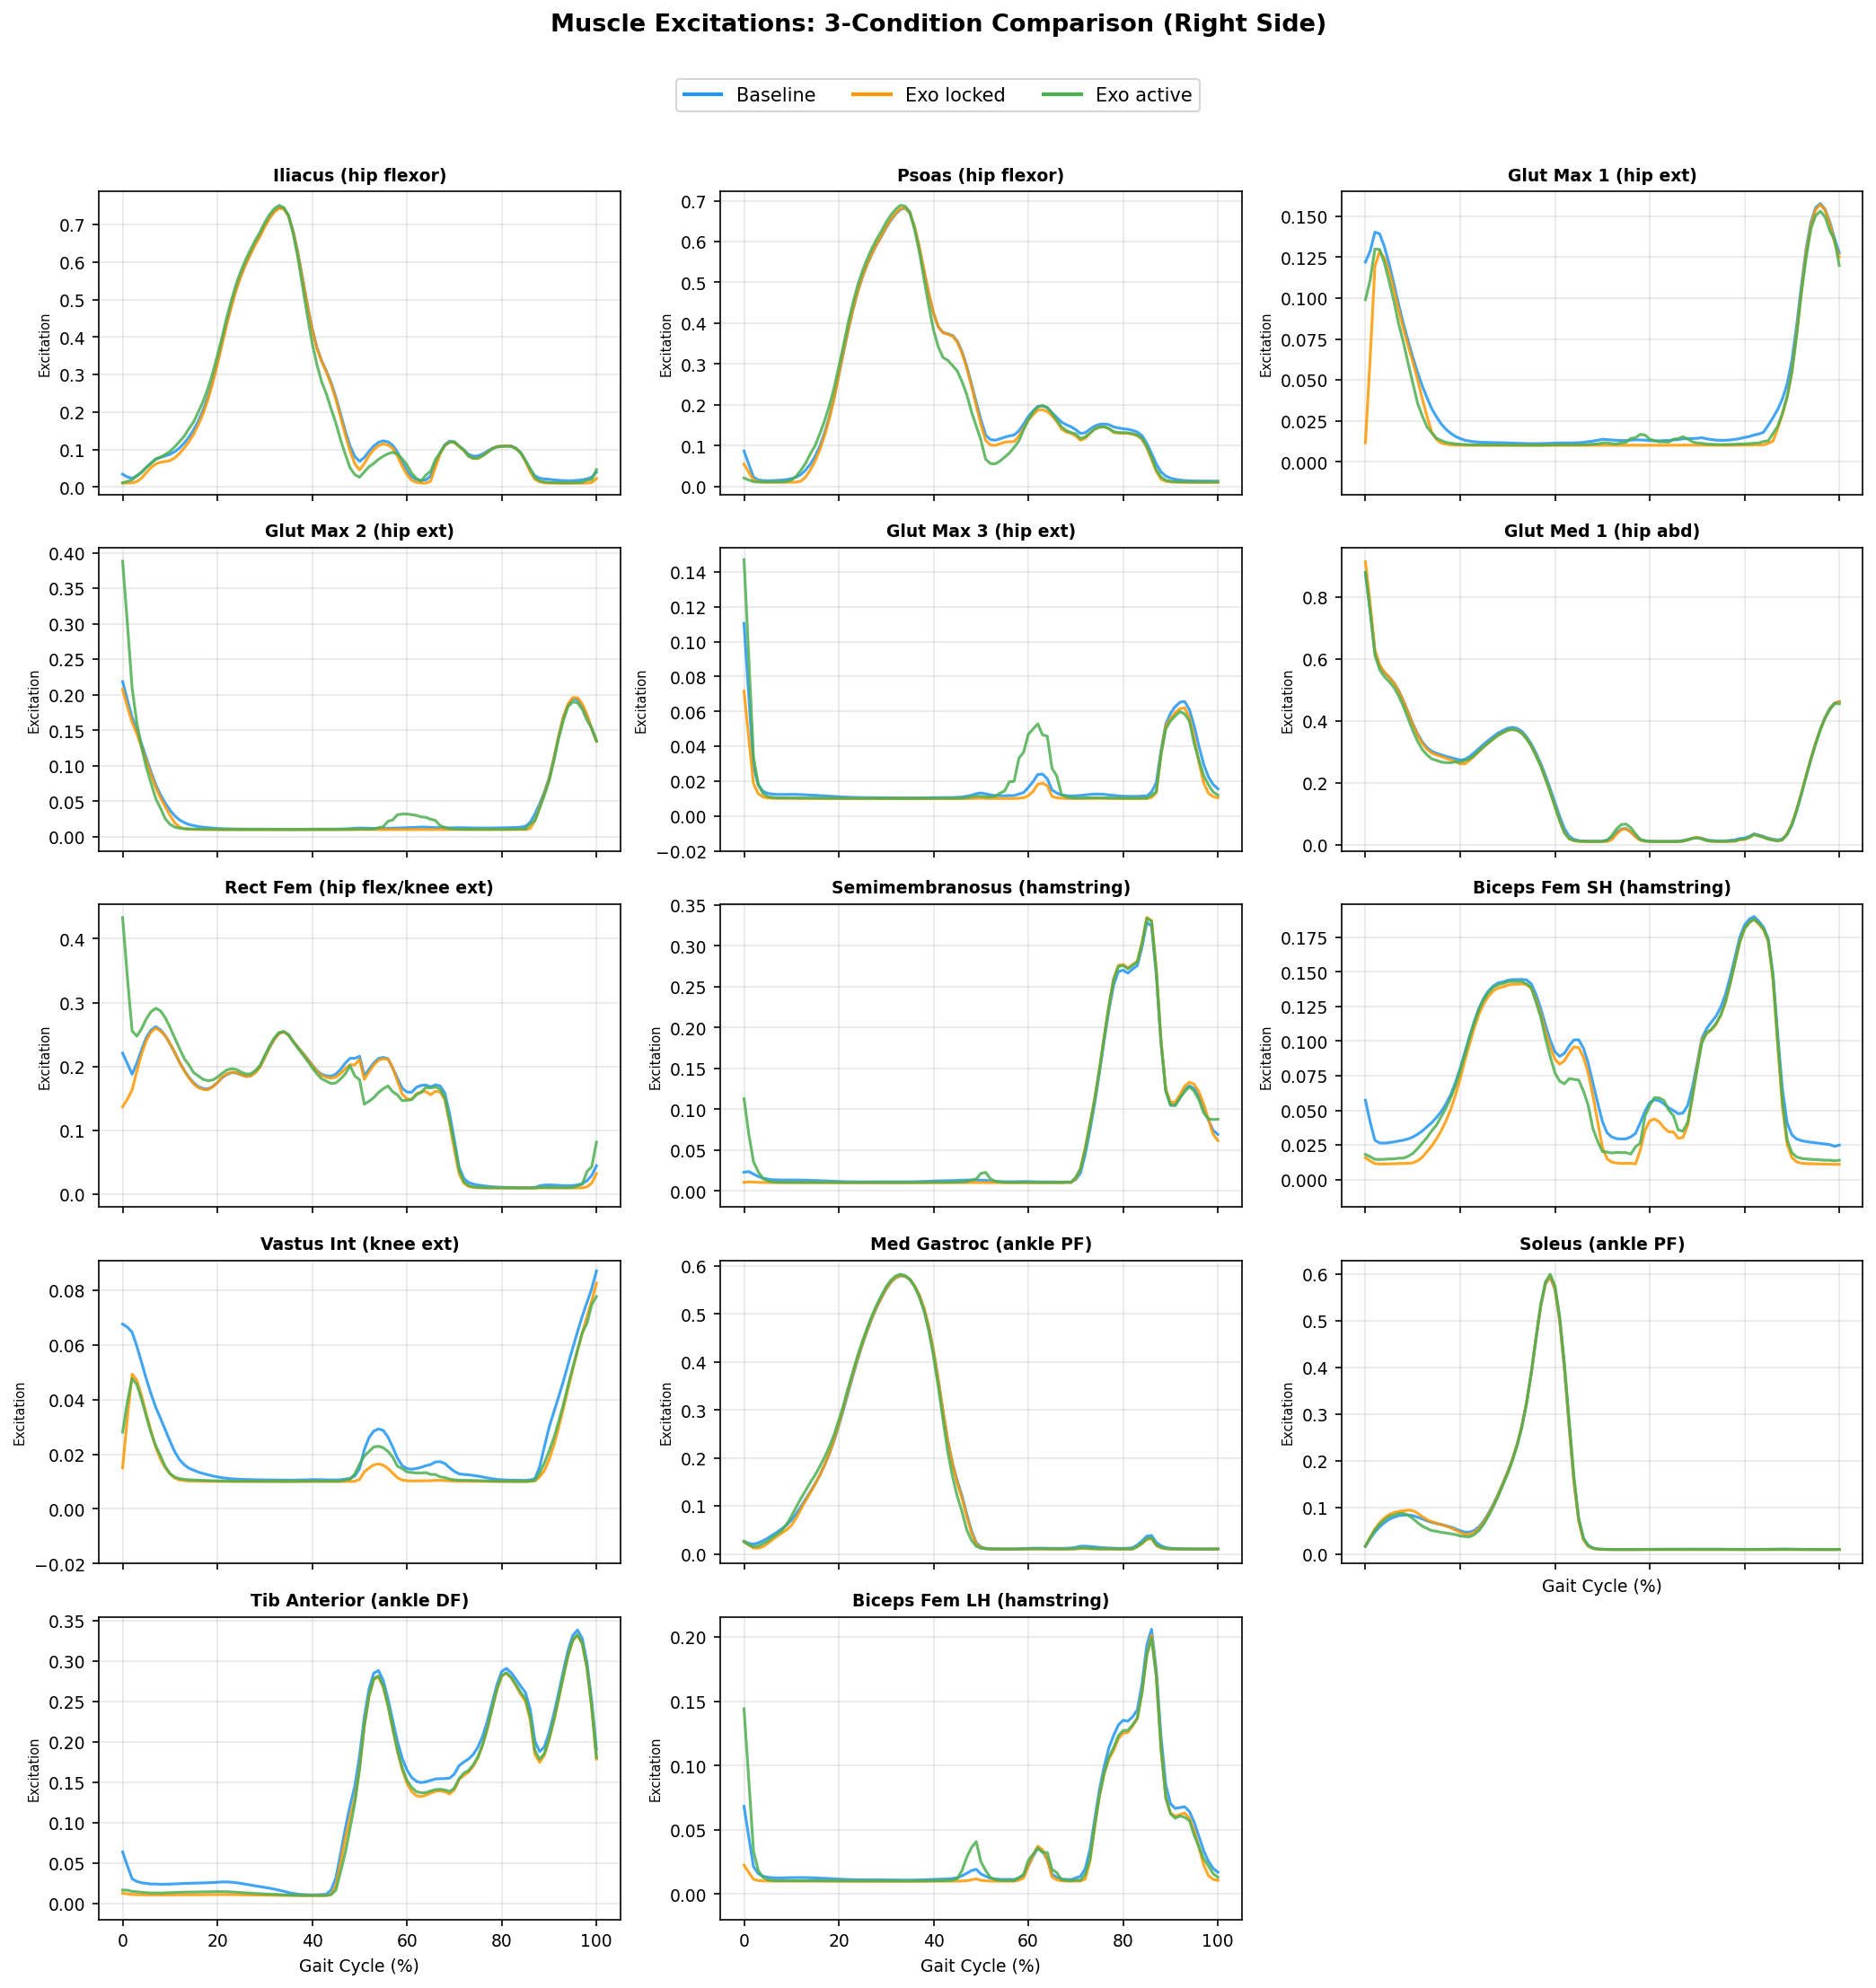

In [4]:
# Fixed muscle names for Rajagopal model
MUSCLES = [
    ('iliacus_r',   'Iliacus (hip flexor)'),
    ('psoas_r',     'Psoas (hip flexor)'),
    ('glmax1_r',    'Glut Max 1 (hip ext)'),
    ('glmax2_r',    'Glut Max 2 (hip ext)'),
    ('glmax3_r',    'Glut Max 3 (hip ext)'),
    ('glmed1_r',    'Glut Med 1 (hip abd)'),
    ('recfem_r',    'Rect Fem (hip flex/knee ext)'),
    ('semimem_r',   'Semimembranosus (hamstring)'),
    ('bfsh_r',      'Biceps Fem SH (hamstring)'),
    ('vasint_r',    'Vastus Int (knee ext)'),
    ('gasmed_r',    'Med Gastroc (ankle PF)'),
    ('soleus_r',    'Soleus (ankle PF)'),
    ('tibant_r',    'Tib Anterior (ankle DF)'),
    ('bflh_r',      'Biceps Fem LH (hamstring)'),
]

def find_col(col_names, muscle):
    """Find activation column — match /forceset/{muscle}/activation"""
    target = f'/forceset/{muscle}/activation'
    if target in col_names:
        return target
    # fallback: partial match
    for col in col_names:
        if f'/{muscle}/' in col:
            return col
    return None

# Re-plot
fig, axes = plt.subplots(5, 3, figsize=(14, 14), sharex=True)
axes = axes.flatten()

for idx, (mname, dname) in enumerate(MUSCLES):
    ax = axes[idx]
    for label, sol in sols.items():
        col = find_col(sol['cols'], mname)
        if col:
            t_pct, exc = to_gait_pct(sol['time'], sol['data'][col])
            ax.plot(t_pct, exc, color=COLORS[label], lw=1.5, alpha=0.85)
    ax.set_title(dname, fontsize=9, fontweight='bold')
    ax.set_ylabel('Excitation', fontsize=7)
    ax.set_ylim(-0.02, None)
    ax.grid(True, alpha=0.3)

for idx in range(len(MUSCLES), len(axes)):
    fig.delaxes(axes[idx])
for idx in range(max(0, len(MUSCLES)-3), len(MUSCLES)):
    axes[idx].set_xlabel('Gait Cycle (%)')

legend_els = [Line2D([0],[0], color=COLORS[l], lw=2, label=l) for l in sols]
fig.legend(handles=legend_els, loc='upper center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, 1.02))
fig.suptitle('Muscle Excitations: 3-Condition Comparison (Right Side)',
             fontsize=13, fontweight='bold', y=1.05)
fig.tight_layout()
plt.show()

## 4. Hip Muscles — Bilateral Focus

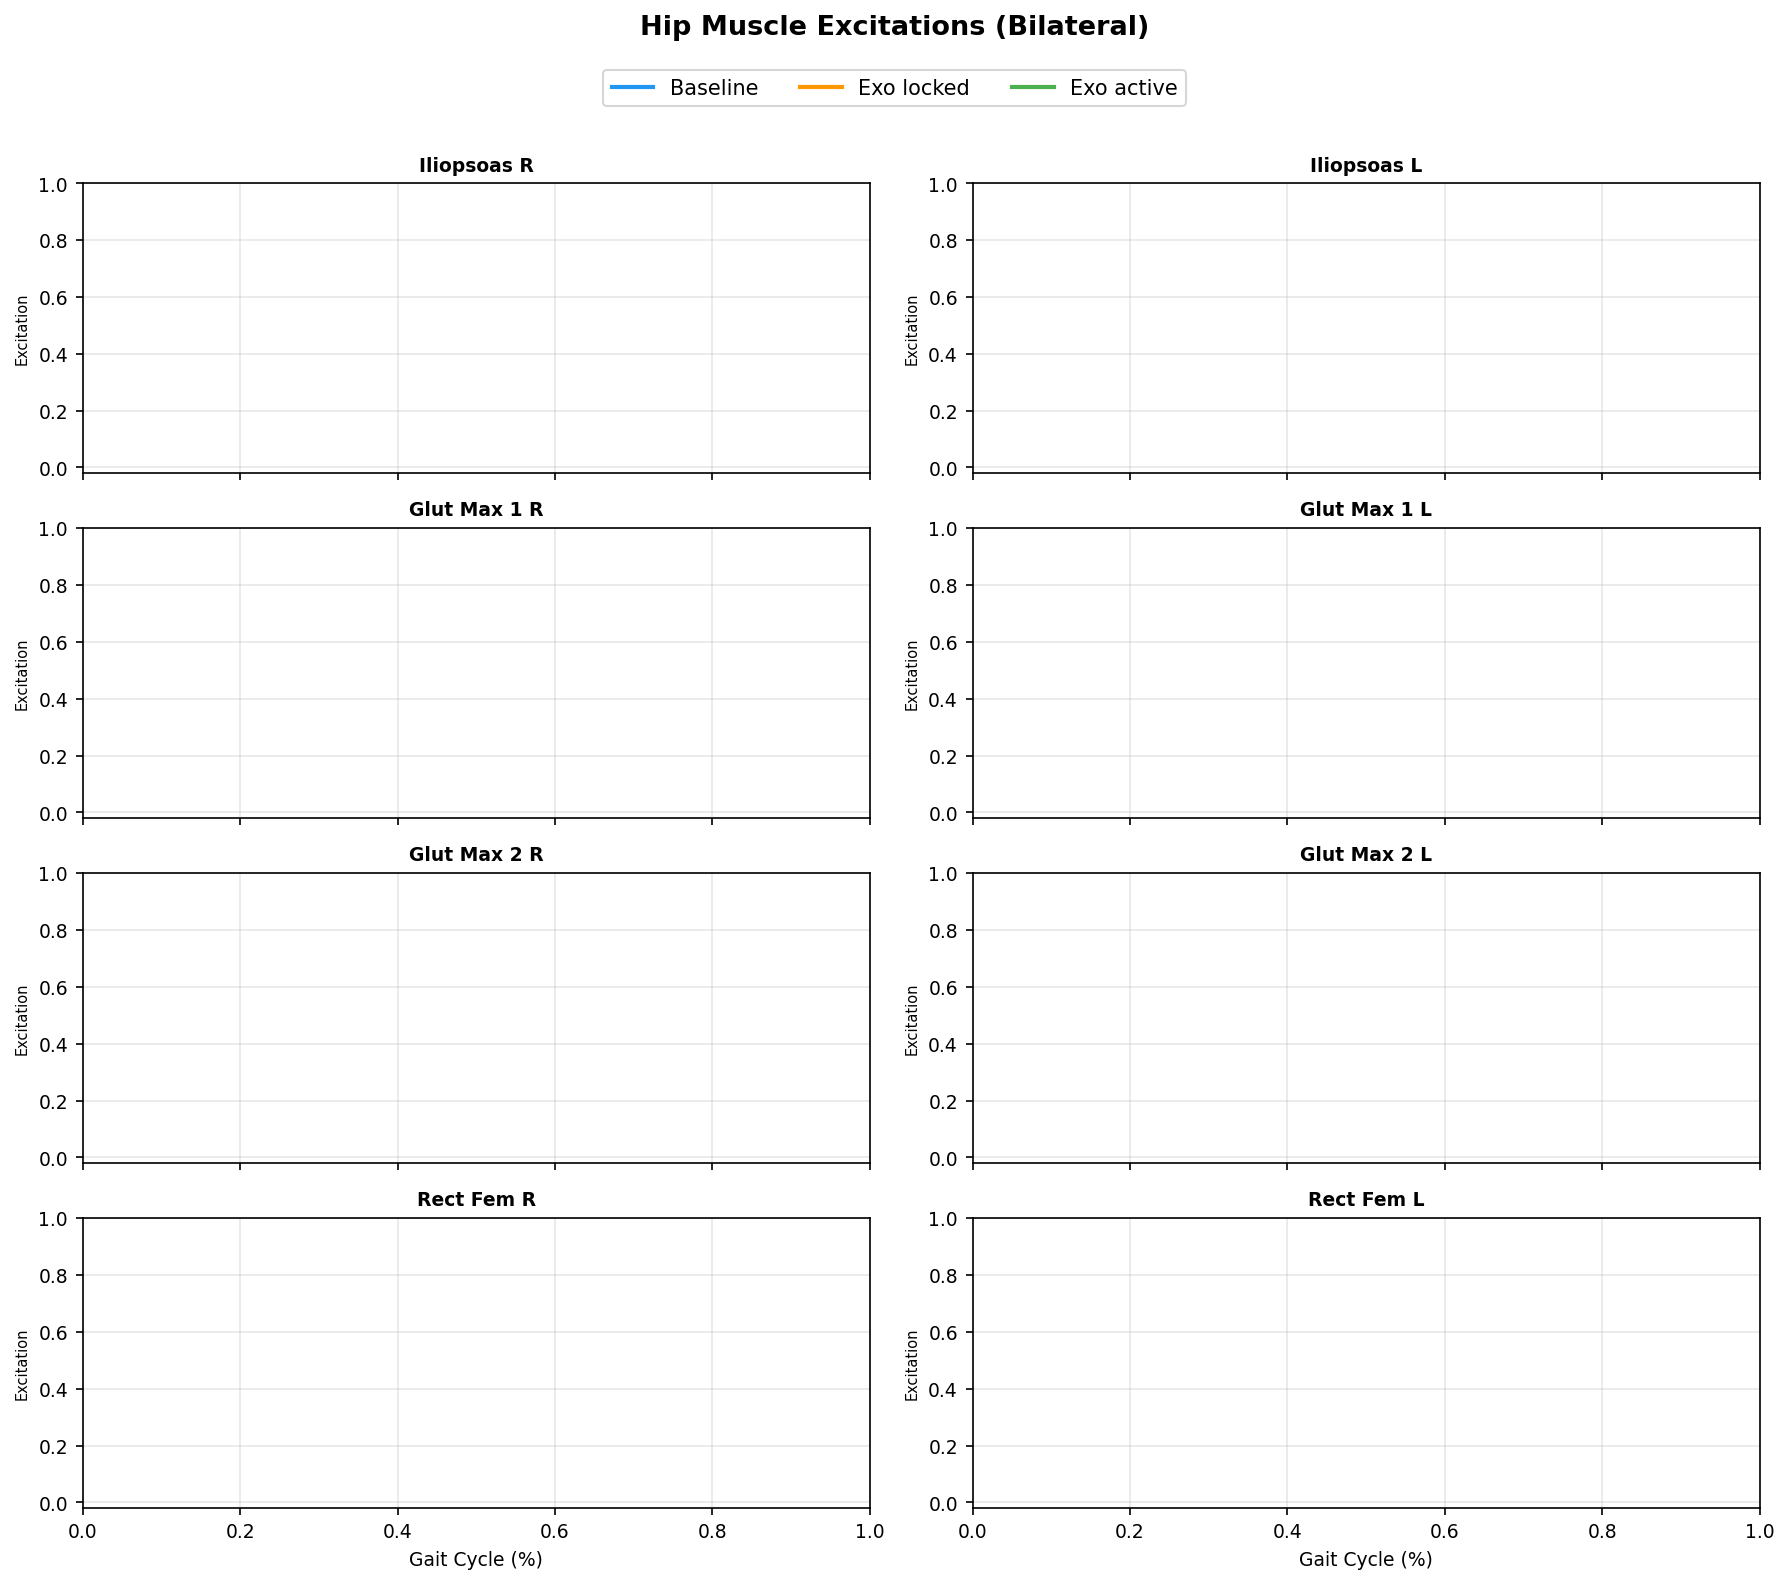

In [5]:
HIP_MUSCLES = [
    ('iliopsoas_r', 'Iliopsoas R'), ('iliopsoas_l', 'Iliopsoas L'),
    ('glut_max1_r', 'Glut Max 1 R'), ('glut_max1_l', 'Glut Max 1 L'),
    ('glut_max2_r', 'Glut Max 2 R'), ('glut_max2_l', 'Glut Max 2 L'),
    ('rect_fem_r',  'Rect Fem R'),   ('rect_fem_l',  'Rect Fem L'),
]

fig, axes = plt.subplots(4, 2, figsize=(12, 10), sharex=True)
axes = axes.flatten()

for idx, (mname, dname) in enumerate(HIP_MUSCLES):
    ax = axes[idx]
    for label, sol in sols.items():
        col = find_col(sol['cols'], mname)
        if col:
            t_pct, exc = to_gait_pct(sol['time'], sol['data'][col])
            ax.plot(t_pct, exc, color=COLORS[label], lw=1.5, alpha=0.85)
    ax.set_title(dname, fontsize=9, fontweight='bold')
    ax.set_ylabel('Excitation', fontsize=7)
    ax.set_ylim(-0.02, None)
    ax.grid(True, alpha=0.3)

for ax in axes[-2:]:
    ax.set_xlabel('Gait Cycle (%)')

legend_els = [Line2D([0],[0], color=COLORS[l], lw=2, label=l) for l in sols]
fig.legend(handles=legend_els, loc='upper center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, 1.02))
fig.suptitle('Hip Muscle Excitations (Bilateral)',
             fontsize=13, fontweight='bold', y=1.05)
fig.tight_layout()
plt.show()

## 5. Total Excitation Effort — Bar Chart

Baseline: effort=2.7200 (179 muscles)
Exo locked: effort=2.6509 (179 muscles)
Exo active: effort=2.6782 (179 muscles)


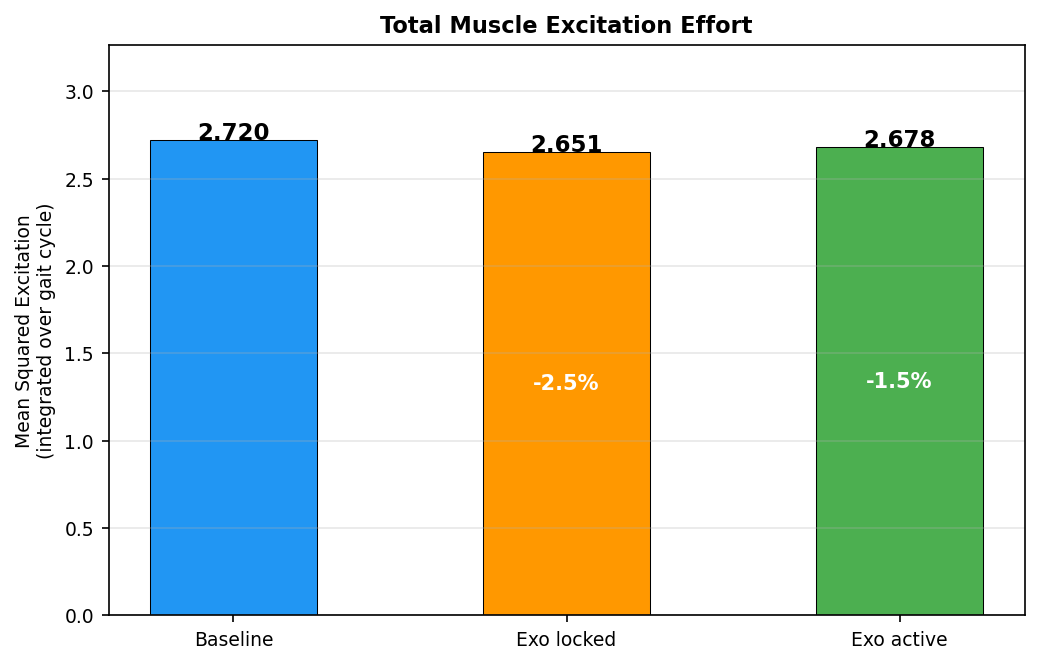

In [6]:
def total_excitation_effort(sol):
    """Integrated mean squared excitation across all muscles."""
    time = sol['time']
    dt = np.diff(time)
    total = 0.0
    n = 0
    for col in sol['cols']:
        if ('/forceset/' in col and
            'reserve' not in col.lower() and
            'exo_hip' not in col and
            col != 'time'):
            exc = sol['data'][col]
            total += np.sum(0.5 * (exc[:-1]**2 + exc[1:]**2) * dt)
            n += 1
    dur = time[-1] - time[0]
    return total / dur if dur > 0 else 0, n

labels, efforts, colors = [], [], []
for label, sol in sols.items():
    eff, nm = total_excitation_effort(sol)
    labels.append(label)
    efforts.append(eff)
    colors.append(COLORS[label])
    print(f'{label}: effort={eff:.4f} ({nm} muscles)')

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(labels, efforts, color=colors, width=0.5,
              edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, efforts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

# % change vs baseline
if len(efforts) >= 2:
    base = efforts[0]
    for i in range(1, len(efforts)):
        pct = (efforts[i] - base) / base * 100
        ax.text(bars[i].get_x() + bars[i].get_width()/2,
                bars[i].get_height()/2,
                f'{pct:+.1f}%', ha='center', va='center',
                fontsize=10, color='white', fontweight='bold')

ax.set_ylabel('Mean Squared Excitation\n(integrated over gait cycle)')
ax.set_title('Total Muscle Excitation Effort', fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, max(efforts) * 1.2)
plt.tight_layout()
plt.show()

## 6. Assistance Torque Profile (Exo Active only)

exo_hip_assist_r: peak=8.0 Nm
exo_hip_assist_l: peak=7.2 Nm


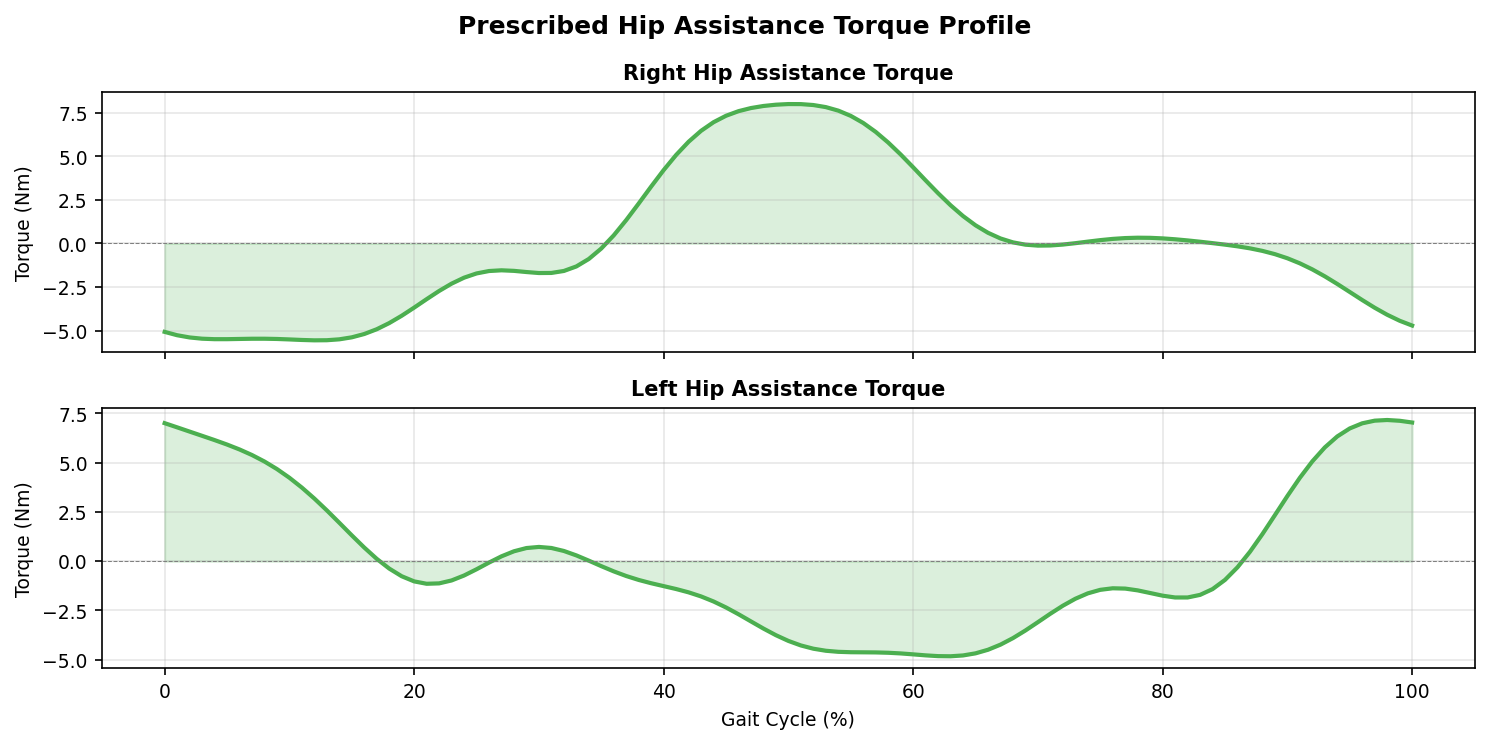

In [7]:
# Load the assistance torque file
assist_path = os.path.join(BASE_DIR, 'exo_active', 'assistance_torques.sto')
if os.path.exists(assist_path):
    t_a, cn_a, dd_a = read_sto(assist_path)
    
    # Trim to the solve window
    mask = (t_a >= 0.48) & (t_a <= 1.61)
    t_trim = t_a[mask]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
    
    for col_name, ax, title in [
        ('exo_hip_assist_r', ax1, 'Right Hip Assistance Torque'),
        ('exo_hip_assist_l', ax2, 'Left Hip Assistance Torque'),
    ]:
        if col_name in dd_a:
            torque = dd_a[col_name][mask]
            t_pct, torque_pct = to_gait_pct(t_trim, torque)
            ax.plot(t_pct, torque_pct, color='#4CAF50', lw=2)
            ax.axhline(0, color='gray', lw=0.5, ls='--')
            ax.fill_between(t_pct, 0, torque_pct, alpha=0.2, color='#4CAF50')
            ax.set_ylabel('Torque (Nm)')
            ax.set_title(title, fontsize=10, fontweight='bold')
            ax.grid(True, alpha=0.3)
            print(f'{col_name}: peak={np.max(np.abs(torque_pct)):.1f} Nm')
    
    ax2.set_xlabel('Gait Cycle (%)')
    fig.suptitle('Prescribed Hip Assistance Torque Profile',
                 fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.show()
else:
    print(f'Not found: {assist_path}')

## 7. Reserve Actuators Check
Reserves should be small — large reserves mean the model can't explain the motion with muscles alone.

In [8]:
for label, sol in sols.items():
    reserves = {c: sol['data'][c] for c in sol['cols']
                if 'reserve' in c.lower()}
    if reserves:
        print(f'\n{label} reserves:')
        for name, vals in reserves.items():
            short = name.split('/')[-1] if '/' in name else name
            print(f'  {short:40s}  peak={np.max(np.abs(vals)):.4f}')
    else:
        print(f'{label}: no reserve columns found')


Baseline reserves:
  reserve_jointset_hip_r_hip_flexion_r      peak=0.0428
  reserve_jointset_hip_r_hip_adduction_r    peak=0.0471
  reserve_jointset_hip_r_hip_rotation_r     peak=0.0578
  reserve_jointset_walker_knee_r_knee_angle_r  peak=0.0326
  reserve_jointset_ankle_r_ankle_angle_r    peak=0.0270
  reserve_jointset_hip_l_hip_flexion_l      peak=0.0356
  reserve_jointset_hip_l_hip_adduction_l    peak=0.0368
  reserve_jointset_hip_l_hip_rotation_l     peak=0.0351
  reserve_jointset_walker_knee_l_knee_angle_l  peak=0.0455
  reserve_jointset_ankle_l_ankle_angle_l    peak=0.0826

Exo locked reserves:
  reserve_jointset_hip_r_hip_flexion_r      peak=0.0490
  reserve_jointset_hip_r_hip_adduction_r    peak=0.0541
  reserve_jointset_hip_r_hip_rotation_r     peak=0.0535
  reserve_jointset_walker_knee_r_knee_angle_r  peak=0.0340
  reserve_jointset_ankle_r_ankle_angle_r    peak=0.0272
  reserve_jointset_hip_l_hip_flexion_l      peak=0.0405
  reserve_jointset_hip_l_hip_adduction_l    peak=0.03

## 8. Save all figures

In [9]:
# Re-run the plots above and save to disk if you want PNGs
OUT = os.path.join(BASE_DIR, 'comparison_results')
os.makedirs(OUT, exist_ok=True)
print(f'Save directory: {OUT}')
print('To save: re-run each cell above, add fig.savefig(...) before plt.show()')
print(f'Then scp to Mac:\n  scp -r wxp@cortex:{OUT}/ ~/Desktop/')

Save directory: /home/wxp/repos/projects/exo-assist-pipeline/opensim/moco-experiments/comparison_results
To save: re-run each cell above, add fig.savefig(...) before plt.show()
Then scp to Mac:
  scp -r wxp@cortex:/home/wxp/repos/projects/exo-assist-pipeline/opensim/moco-experiments/comparison_results/ ~/Desktop/
